In [13]:
import os
import numpy as np
import cv2
import glob as glob

import tensorflow as tf
import tensorflow_hub as hub

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from zipfile import ZipFile
from urllib.request import urlretrieve

import warnings
import logging
import absl

#filter absl warnings
warnings.filterwarnings("ignore", module="absl")

#capture all warnings in logging system
logging.captureWarnings(True)

#set the absl logger level to 'error' to suppress warnings
absl_logger = logging.getLogger("absl")
absl_logger.setLevel(logging.ERROR)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [4]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assets....", end="")

    #download zip file
    urlretrieve(url, save_path)

    try:
        #extracting zip file
        with ZipFile(save_path) as z:
            #extract zip file content from the same directory
            z.extractall(os.path.split(save_path)[0]) 

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [9]:
URL = r"https://www.dropbox.com/s/wad5js22fbeo1be/camvid_images.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "camvid_image.zip")

#download if zip doesn't exists
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

In [10]:
image_paths = sorted(glob.glob("camvid_images" + os.sep + "*.png"))

for idx in range(len(image_paths)):
    print(image_paths[idx])

camvid_images\camvid_sample_1.png
camvid_images\camvid_sample_2.png
camvid_images\camvid_sample_3.png
camvid_images\camvid_sample_4.png


In [14]:
def load_image(path):
    image = cv2.imread(path)

    #convert image in BGR format to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #add batch dimension
    image = np.expand_dims(image, axis=0) / 255.0

    return image

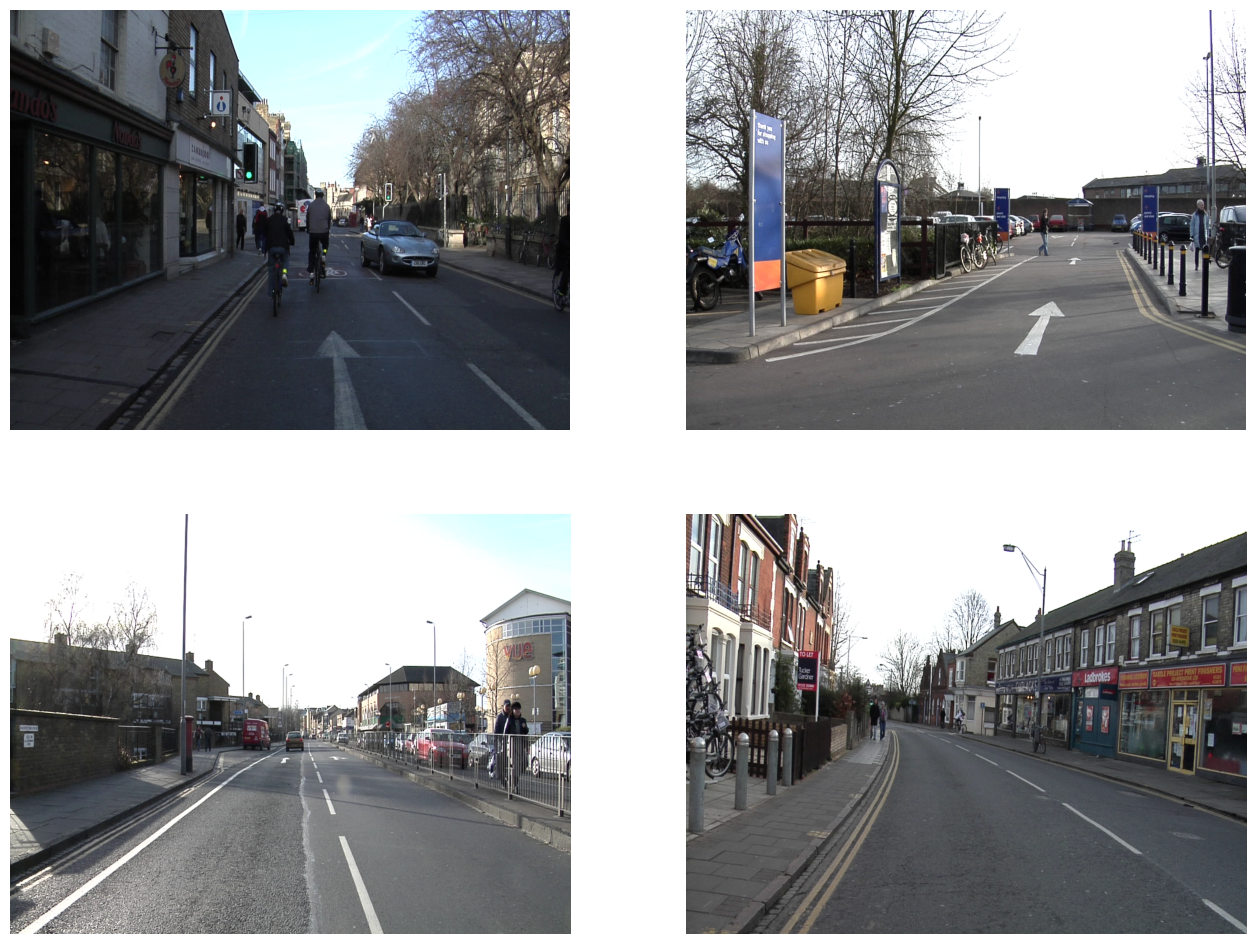

In [16]:
images = []
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,12))

for idx, axis in enumerate(ax.flat):
    image = load_image(image_paths[idx])
    images.append(image)
    axis.imshow(image[0])
    axis.axis("off")
plt.show()

In [ ]:
#define dictionary that maps all 32 classes in CamVid dataset with their id ans rgb color label
class_index = \
    {
         0: [(64, 128, 64),  'Animal'],
         1: [(192, 0, 128),  'Archway'],
         2: [(0, 128, 192),  'Bicyclist'],
         3: [(0, 128, 64),   'Bridge'],
         4: [(128, 0, 0),    'Building'],
         5: [(64, 0, 128),   'Car'],
         6: [(64, 0, 192),   'Cart/Luggage/Pram'],
         7: [(192, 128, 64), 'Child'],
         8: [(192, 192, 128),'Column Pole'],
         9: [(64, 64, 128),  'Fence'],
        10: [(128, 0, 192),  'LaneMkgs Driv'],
        11: [(192, 0, 64),   'LaneMkgs NonDriv'],
        12: [(128, 128, 64), 'Misc Text'],
        13: [(192, 0, 192),  'Motorcycle/Scooter'],
        14: [(128, 64, 64),  'Other Moving'],
        15: [(64, 192, 128), 'Parking Block'],
        16: [(64, 64, 0),    'Pedestrian'],
        17: [(128, 64, 128), 'Road'],
        18: [(128, 128, 192),'Road Shoulder'],
        19: [(0, 0, 192),    'Sidewalk'],
        20: [(192, 128, 128),'Sign Symbol'],
        21: [(128, 128, 128),'Sky'],
        22: [(64, 128, 192), 'SUV/Pickup/Truck'],
        23: [(0, 0, 64),     'Traffic Cone'],
        24: [(0, 64, 64),    'Traffic Light'],
        25: [(192, 64, 128), 'Train'],
        26: [(128, 128, 0),  'Tree'],
        27: [(192, 128, 192),'Truck/Bus'],
        28: [(64, 0, 64),    'Tunnel'],
        29: [(192, 192, 0),  'Vegetation Misc'],
        30: [(0, 0, 0),      'Void'],
        31: [(64, 192, 0),   'Wall']  
    }

In [18]:
#load model from tensorflow_hub
model_url = "https://tfhub.dev/google/HRNet/camvid-hrnetv2-w48/1"
print("loading model:", model_url)

seg_model = hub.load(model_url)
print("\nmodel loaded!")

loading model: https://tfhub.dev/google/HRNet/camvid-hrnetv2-w48/1




model loaded!


In [19]:
#make prediction using first image
pred_mask = seg_model.predict(images[0])

#predicted mask has the following shape: [B, H, W, C]
print("Shape of predicted mask:", pred_mask.shape)

Shape of predicted mask: (1, 720, 960, 33)


In [20]:
# remove batch dimension and background class
pred_mask = pred_mask.numpy()

#1st label is the background class added by the model, let's remove it from the dataset
pred_mask = pred_mask[:, :, :, 1:]

#remove batch dimension
pred_mask = np.squeeze(pred_mask)

#print shape [H, W, C]
print("Shape of the predictedd mask after removal of batch dimension and background class:", pred_mask.shape)



Shape of the predictedd mask after removal of batch dimension and background class: (720, 960, 32)


(np.float64(-0.5), np.float64(959.5), np.float64(719.5), np.float64(-0.5))

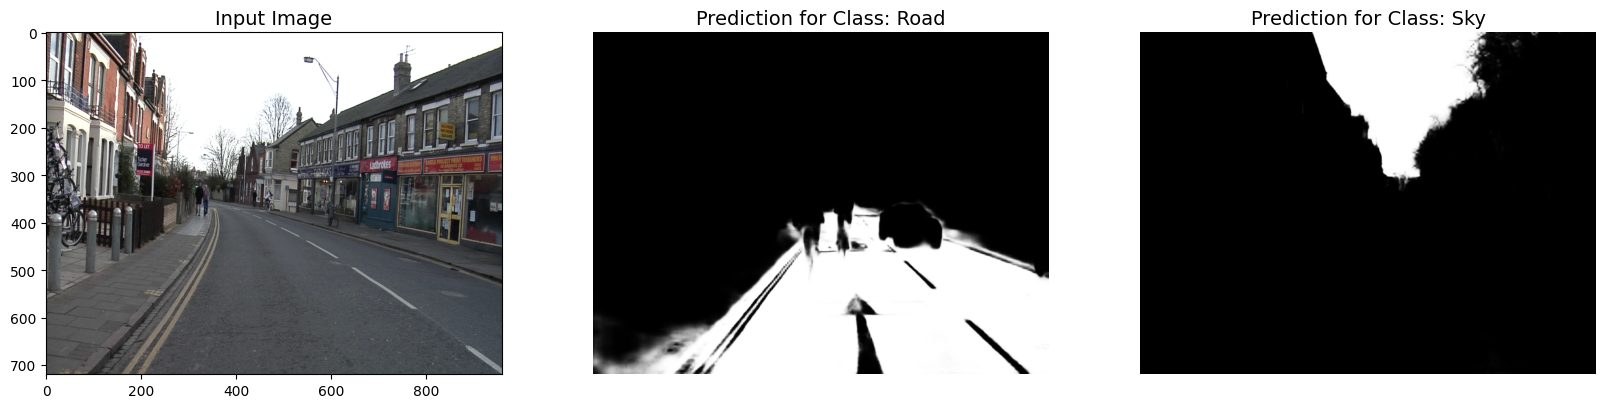

In [21]:
#visualise reult
#each channel in pred_mask contians probabilities that the pixels
#in the original image are associated with the class for that channel.
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title("Input Image", fontsize=14)
plt.imshow(np.squeeze(image[0]))

plt.subplot(1, 3, 2)
plt.title("Prediction for Class: Road", fontsize=14)
plt.imshow(pred_mask[:, :, 17], cmap="gray")# class 17 is 'road' class
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Prediction for Class: Sky", fontsize=14)
plt.imshow(pred_mask[:, :, 21], cmap="gray")# class 21 is 'sky' class
plt.axis("off")